# Bloque A: JSON Juegos de Steam

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Carga del JSON
with open('../data/raw/games.json', 'r', encoding='utf-8') as f:
    games_raw = json.load(f)

# Convertir a DataFrame
df_games = pd.DataFrame.from_dict(games_raw, orient='index').reset_index()
df_games = df_games.rename(columns={'index': 'appid'})

print(f"Total de juegos cargados: {len(df_games)}")
print(f"\nColumnas disponibles ({len(df_games.columns)}):")
print(df_games.columns.tolist())


Total de juegos cargados: 65686

Columnas disponibles (22):
['appid', 'name', 'release_date', 'required_age', 'price', 'detailed_description', 'about_the_game', 'short_description', 'supported_languages', 'full_audio_languages', 'categories', 'genres', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags']


In [32]:
df_games

,appid,name,release_date,required_age,price,detailed_description,about_the_game,short_description,supported_languages,full_audio_languages,...,total_votos,positive_ratio,release_date_parsed,release_year,release_month,owners_midpoint,is_free,total_votes,num_languages,is_successful_proxy
0,1724540,Welcome to Goodland,"Apr 28, 2023",0,16.99,Join our Discord! About the Game You could nev...,You could never have known you would end up in...,It is a strategy/adventure game set in a small...,[English],[],...,33,0.757576,2023-04-28,2023,4,10000.0,False,33,1,0
1,2201840,그녀가 다시 노래할 때까지.,"Nov 14, 2022",0,4.99,ABOUT THE GAME 'Until She sings again' is a ro...,ABOUT THE GAME 'Until She sings again' is a ro...,My friend has become a girl after I came back ...,[Korean],[Korean],...,10,0.800000,2022-11-14,2022,11,10000.0,False,10,1,0
2,1364180,Counter Operation Online,"Nov 1, 2020",0,14.99,Counter Operation Online (COO) shooter require...,Counter Operation Online (COO) shooter require...,Counter Operation Online ( COO ) revived by th...,[English],[English],...,2,0.500000,2020-11-01,2020,11,10000.0,False,2,1,0
3,2218750,Halls of Torment,"Sep 24, 2024",0,6.66,Halls of Torment is a horde survival game with...,Halls of Torment is a horde survival game with...,Slay hordes of terrifying monsters in this hor...,"[English, French, Italian, German, Spanish - S...","[English, Ukrainian]",...,25142,0.958476,2024-09-24,2024,9,750000.0,False,25142,15,1
4,3262620,剑武玄幻之旅,"Oct 31, 2024",0,3.39,玄幻类文字挂机冒险游戏，探索一个系统丰富且娱乐快捷的放置世界 少年穿越异世，一路成长，屡遭奇...,玄幻类文字挂机冒险游戏，探索一个系统丰富且娱乐快捷的放置世界 少年穿越异世，一路成长，屡遭奇...,一款玄幻类的文字挂机冒险游戏，可放置可探索剧情，即刻进入一个系统丰富且娱乐快捷的挂机世界吧！,[Simplified Chinese],[],...,10,0.800000,2024-10-31,2024,10,10000.0,False,10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65681,2063120,Box To The Beat VR,"Aug 22, 2023",0,19.99,Join our Discord! Join our Discord to compare ...,Are You Ready For The Ultimate Rhythm Boxing S...,"Enjoy constant updates and free songs, custom ...","[English, Simplified Chinese, French, Italian,...","[English, Simplified Chinese, French, Japanese...",...,84,0.964286,2023-08-22,2023,8,10000.0,False,84,8,0
65682,1901830,SønderDø,"May 13, 2022",0,1.99,You wake up at your school. You only have a fl...,You wake up at your school. You only have a fl...,You have to survive the night until 08:00/8 AM...,[English],[English],...,4,1.000000,2022-05-13,2022,5,35000.0,False,4,1,0
65683,1028310,BOOK OF HOURS,"Aug 17, 2023",0,24.99,"For fifteen centuries, Hush House was a fortre...","For fifteen centuries, Hush House was a fortre...",Restore a crumbling occult library by a winter...,"[English, Russian, Simplified Chinese]",[],...,3916,0.841931,2023-08-17,2023,8,350000.0,False,3916,3,0
65684,3074770,"FFS, Another Northern Duke?!","Aug 26, 2024",0,15.00,There's only one goal here: survive. Seduce th...,There's only one goal here: survive. Seduce th...,There's only one goal here: survive. Seduce th...,[English],[],...,0,NaN,2024-08-26,2024,8,10000.0,False,0,1,0


In [2]:
print("=== TIPOS DE DATOS ===")
print(df_games.dtypes)

print("\n=== VALORES NULOS ===")
nulos = df_games.isnull().sum()
nulos_pct = (nulos / len(df_games) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('porcentaje', ascending=False))


=== TIPOS DE DATOS ===
appid                           str
name                            str
release_date                    str
required_age                  int64
price                       float64
detailed_description            str
about_the_game                  str
short_description               str
supported_languages          object
full_audio_languages         object
categories                   object
genres                       object
positive                      int64
negative                      int64
estimated_owners                str
average_playtime_forever      int64
average_playtime_2weeks       int64
median_playtime_forever       int64
median_playtime_2weeks        int64
discount                     object
peak_ccu                      int64
tags                         object
dtype: object

=== VALORES NULOS ===
Empty DataFrame
Columns: [nulos, porcentaje]
Index: []


C:\Users\longm\AppData\Local\Temp\ipykernel_12240\1952938799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


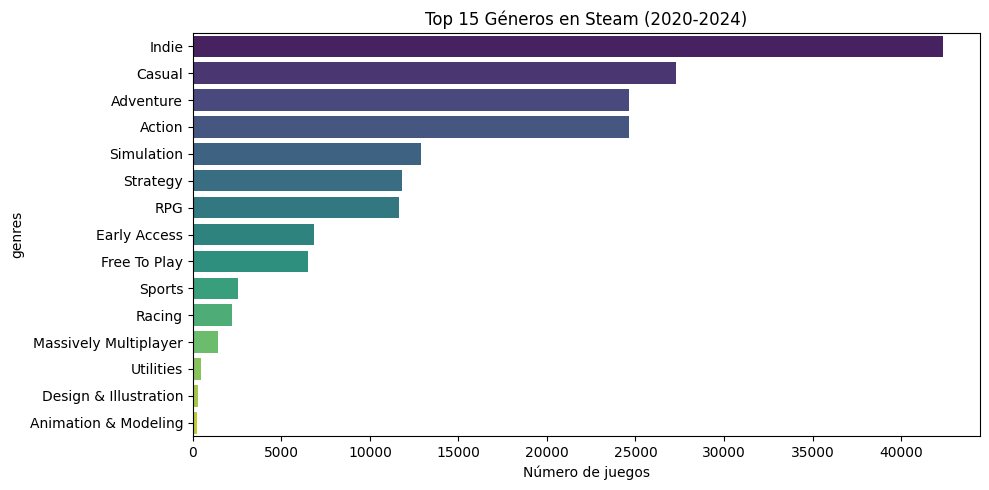

In [3]:
# Los géneros vienen como lista, hay que explotarlos
df_genres = df_games[['appid', 'genres']].dropna()
df_genres = df_genres.explode('genres')

top_genres = df_genres['genres'].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 15 Géneros en Steam (2020-2024)')
plt.xlabel('Número de juegos')
plt.tight_layout()
plt.show()


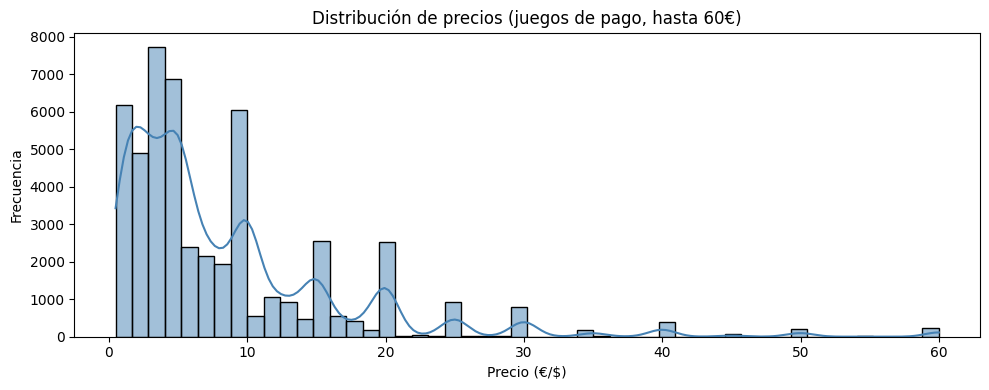


Juegos gratuitos (price == 0): 14958
Juegos de pago (price > 0): 50728


In [4]:
df_precio = df_games[df_games['price'] > 0]['price']  # Excluir gratuitos para ver distribución

plt.figure(figsize=(10, 4))
sns.histplot(df_precio[df_precio < 60], bins=50, kde=True, color='steelblue')
plt.title('Distribución de precios (juegos de pago, hasta 60€)')
plt.xlabel('Precio (€/$)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(f"\nJuegos gratuitos (price == 0): {(df_games['price'] == 0).sum()}")
print(f"Juegos de pago (price > 0): {(df_games['price'] > 0).sum()}")


In [5]:
# Calcular el ratio de positivos sobre total de votos
df_games['total_votos'] = df_games['positive'] + df_games['negative']
df_games['positive_ratio'] = df_games['positive'] / df_games['total_votos']

# Ver cuántos juegos pasarían el umbral de éxito (100 votos y 90% positivos)
exitosos = df_games[
    (df_games['total_votos'] >= 100) & 
    (df_games['positive_ratio'] >= 0.90)
]

print(f"Total juegos con datos de votos: {df_games['total_votos'].notna().sum()}")
print(f"Juegos con >= 100 votos: {(df_games['total_votos'] >= 100).sum()}")
print(f"Juegos 'exitosos' (>=100 votos y >=90% positivos): {len(exitosos)}")
print(f"Porcentaje sobre el total: {len(exitosos)/len(df_games)*100:.2f}%")


Total juegos con datos de votos: 65686
Juegos con >= 100 votos: 9135
Juegos 'exitosos' (>=100 votos y >=90% positivos): 3171
Porcentaje sobre el total: 4.83%


##  Bloque A: EDA del JSON — Conclusiones

### Dataset
- El JSON contiene **65.686 juegos** de Steam lanzados entre 2020 y 2024.
- **Sin valores nulos** en ninguna columna.

### Distribución de precios
- **14.958 juegos gratuitos (22,8%)** y **50.728 de pago (77,2%)**.
- La distribución de precios sigue una **cola larga derecha** típica del 
  mercado indie: alta concentración entre 0€ y 10€, con picos claros en 4,99€, 9,99€ y 19,99€.

### Géneros
- **Indie** domina claramente (~42.000 juegos), seguido de Casual, 
  Adventure y Action.
- "Early Access" aparece como género, lo que es relevante para el modelado: 
  los juegos en Early Access tienen patrones de recepción diferentes.

### Votos (positive/negative en el JSON)
- Los campos `positive` y `negative` del JSON son **conteos acumulados de 
  votos** (pulgar arriba/abajo) desde el lanzamiento hasta enero 2025
- Solo **9.135 juegos (13,9%)** superan los 100 votos totales.
- Solo **3.171 juegos (4,83%)** superan simultáneamente los 100 votos y 
  el 90% de positividad.
-  **Limitación metodológica:** estos campos no tienen granularidad 
  temporal, por lo que **no pueden usarse como variable objetivo** para la 
  predicción temprana (T+180 días). La variable objetivo real se construirá 
  a partir del conteo y las fechas de los CSV de reseñas escritas.
  Los campos `positive`/`negative` del JSON se utilizarán únicamente como 
  **features descriptivas** del estado final del juego (variables auxiliares).


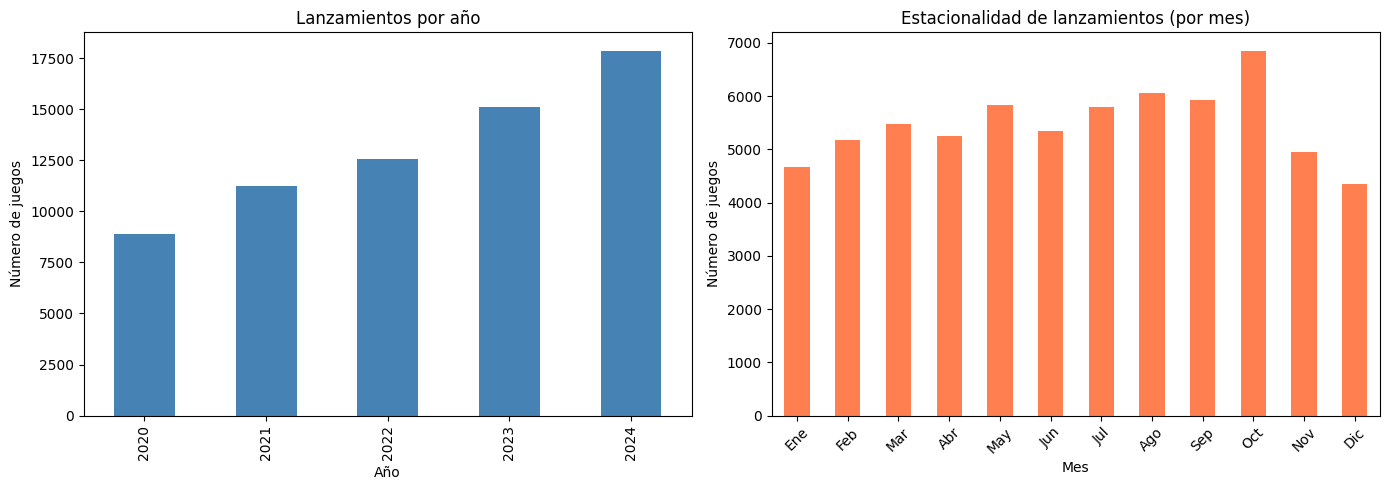

In [6]:
# Convertir release_date a datetime
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], format='mixed', errors='coerce')
df_games['release_year'] = df_games['release_date_parsed'].dt.year
df_games['release_month'] = df_games['release_date_parsed'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por año
df_games['release_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Lanzamientos por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de juegos')

# Por mes (estacionalidad)
df_games['release_month'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Estacionalidad de lanzamientos (por mes)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Número de juegos')
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=45)

plt.tight_layout()
plt.show()



C:\Users\longm\AppData\Local\Temp\ipykernel_12240\2996290890.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=owners_counts.values, y=owners_counts.index, palette='magma')


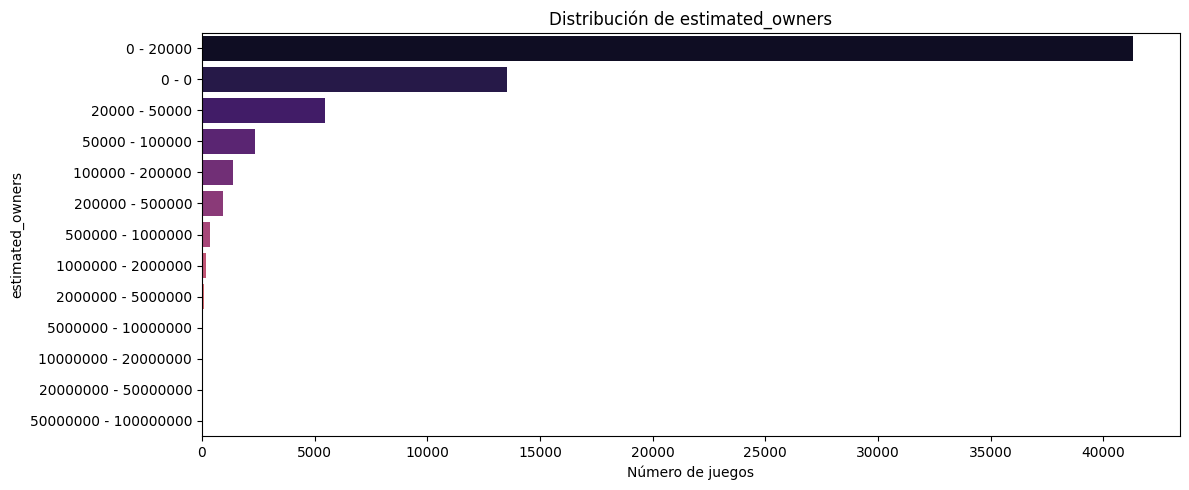


Estadísticas de owners_midpoint:
count    6.568600e+04
mean     5.104680e+04
std      8.689919e+05
min      0.000000e+00
25%      1.000000e+04
50%      1.000000e+04
75%      1.000000e+04
max      7.500000e+07
Name: owners_midpoint, dtype: float64

Juegos con 0 owners estimados: 13521


In [7]:
# estimated_owners viene como string tipo "0 - 20000", hay que procesarlo
def parsear_owners(owners_str):
    if not isinstance(owners_str, str):
        return None
    partes = owners_str.replace(',', '').split(' - ')
    try:
        return (int(partes[0]) + int(partes[1])) / 2  # Punto medio del rango
    except:
        return None

df_games['owners_midpoint'] = df_games['estimated_owners'].apply(parsear_owners)

# Distribución de rangos de owners
owners_counts = df_games['estimated_owners'].value_counts()
plt.figure(figsize=(12, 5))
sns.barplot(x=owners_counts.values, y=owners_counts.index, palette='magma')
plt.title('Distribución de estimated_owners')
plt.xlabel('Número de juegos')
plt.tight_layout()
plt.show()

print("\nEstadísticas de owners_midpoint:")
print(df_games['owners_midpoint'].describe())
print(f"\nJuegos con 0 owners estimados: {(df_games['owners_midpoint'] == 0).sum()}")


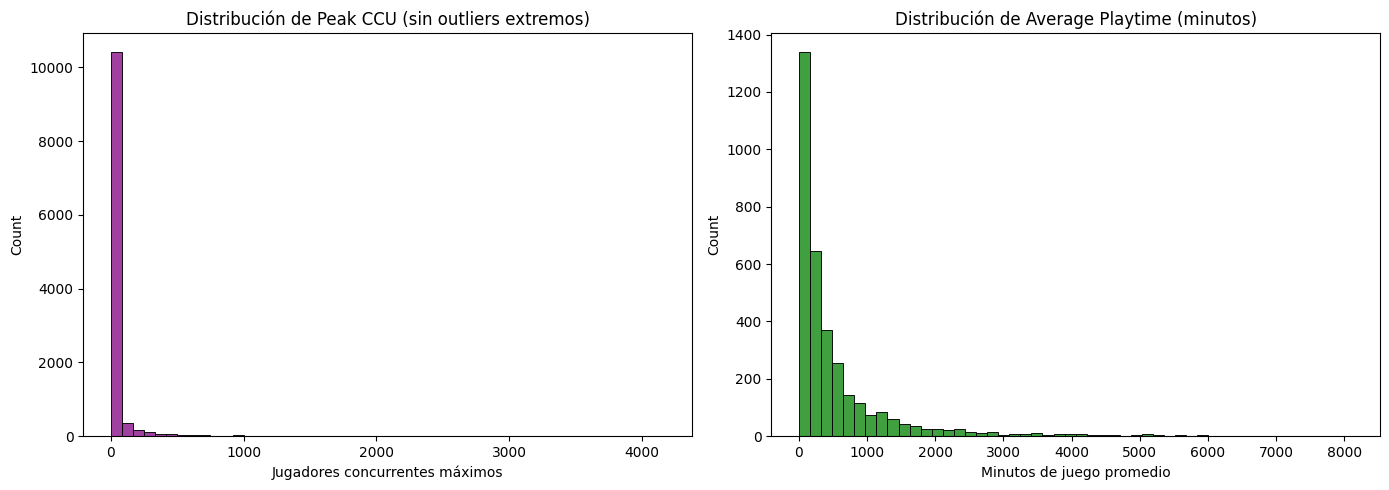

Juegos con peak_ccu = 0: 54046 (82.3%)
Juegos con playtime = 0: 62231 (94.7%)

Top 5 juegos por peak_ccu:
                     name  peak_ccu
62934       Call of Duty®    246142
19239  NARAKA: BLADEPOINT    225393
64000       Apex Legends™    148971
62608  Black Myth: Wukong     86447
42474            Factorio     61667


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak CCU (excluyendo outliers extremos para visualizar)
peak_ccu_filtered = df_games[df_games['peak_ccu'] > 0]['peak_ccu']
sns.histplot(peak_ccu_filtered[peak_ccu_filtered < peak_ccu_filtered.quantile(0.99)], 
             bins=50, ax=axes[0], color='purple')
axes[0].set_title('Distribución de Peak CCU (sin outliers extremos)')
axes[0].set_xlabel('Jugadores concurrentes máximos')

# Average playtime
playtime_filtered = df_games[df_games['average_playtime_forever'] > 0]['average_playtime_forever']
sns.histplot(playtime_filtered[playtime_filtered < playtime_filtered.quantile(0.99)], 
             bins=50, ax=axes[1], color='green')
axes[1].set_title('Distribución de Average Playtime (minutos)')
axes[1].set_xlabel('Minutos de juego promedio')

plt.tight_layout()
plt.show()

print(f"Juegos con peak_ccu = 0: {(df_games['peak_ccu'] == 0).sum()} ({(df_games['peak_ccu'] == 0).sum()/len(df_games)*100:.1f}%)")
print(f"Juegos con playtime = 0: {(df_games['average_playtime_forever'] == 0).sum()} ({(df_games['average_playtime_forever'] == 0).sum()/len(df_games)*100:.1f}%)")
print(f"\nTop 5 juegos por peak_ccu:")
print(df_games[['name','peak_ccu']].sort_values('peak_ccu', ascending=False).head())


C:\Users\longm\AppData\Local\Temp\ipykernel_12240\4242213186.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ratio, x='is_free', y='positive_ratio', ax=axes[0], palette='Set2')
C:\Users\longm\AppData\Local\Temp\ipykernel_12240\4242213186.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['De pago', 'Gratuito'])


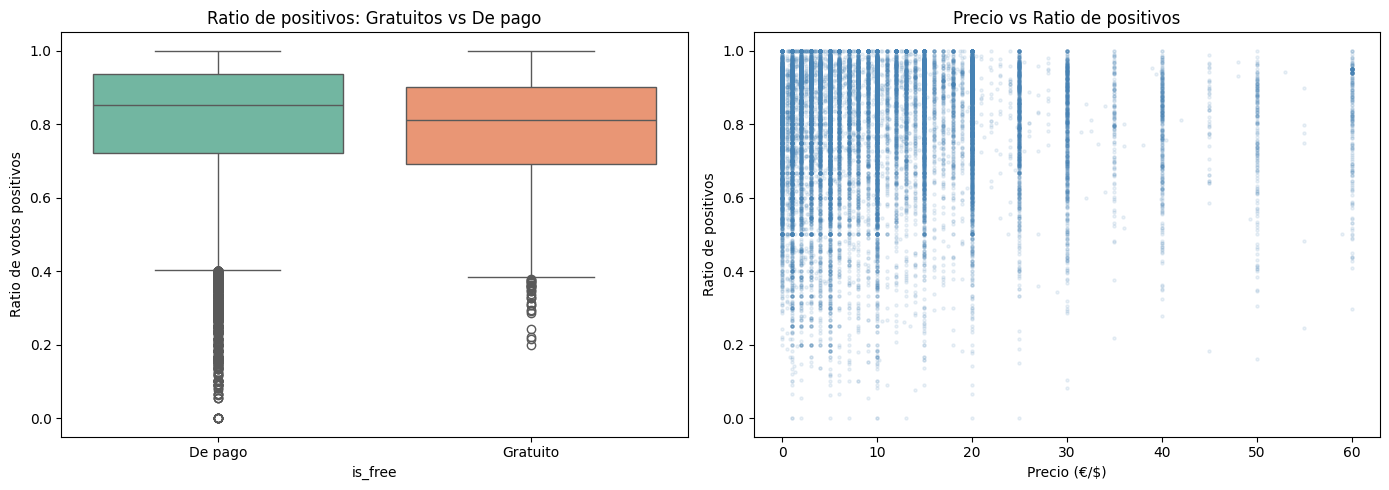

Media de ratio positivos por tipo:
             mean    median  count
is_free                           
False    0.808866  0.851852  24695
True     0.781931  0.810811   2305


In [9]:
df_games['is_free'] = df_games['price'] == 0
df_games['total_votes'] = df_games['positive'] + df_games['negative']
df_games['positive_ratio'] = df_games['positive'] / df_games['total_votes']

# Solo juegos con suficientes votos para que el ratio sea significativo
df_ratio = df_games[df_games['total_votes'] >= 10].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot ratio positivos por tipo de juego
sns.boxplot(data=df_ratio, x='is_free', y='positive_ratio', ax=axes[0], palette='Set2')
axes[0].set_title('Ratio de positivos: Gratuitos vs De pago')
axes[0].set_xticklabels(['De pago', 'Gratuito'])
axes[0].set_ylabel('Ratio de votos positivos')

# Precio vs ratio positivos (scatter)
df_scatter = df_ratio[df_ratio['price'] < 60]
axes[1].scatter(df_scatter['price'], df_scatter['positive_ratio'], alpha=0.1, s=5, color='steelblue')
axes[1].set_title('Precio vs Ratio de positivos')
axes[1].set_xlabel('Precio (€/$)')
axes[1].set_ylabel('Ratio de positivos')

plt.tight_layout()
plt.show()

print("Media de ratio positivos por tipo:")
print(df_ratio.groupby('is_free')['positive_ratio'].agg(['mean','median','count']))


C:\Users\longm\AppData\Local\Temp\ipykernel_12240\754264541.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_stats['median'], y=genre_stats.index, palette='coolwarm')


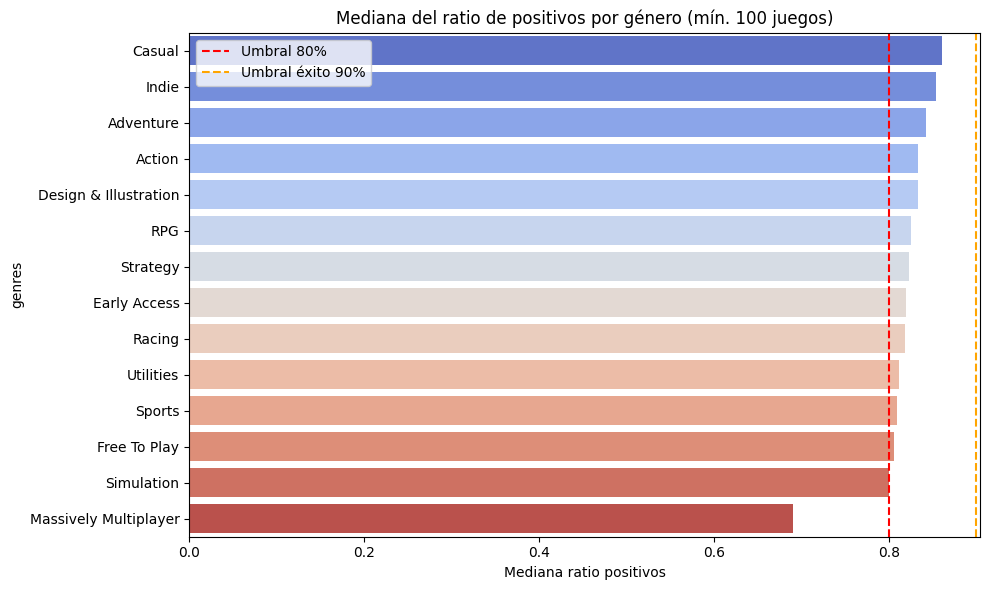

In [10]:
df_genre_ratio = df_games[df_games['total_votes'] >= 10][['appid', 'genres', 'positive_ratio']].dropna()
df_genre_ratio = df_genre_ratio.explode('genres')

genre_stats = df_genre_ratio.groupby('genres')['positive_ratio'].agg(['mean','median','count'])
genre_stats = genre_stats[genre_stats['count'] >= 100].sort_values('median', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_stats['median'], y=genre_stats.index, palette='coolwarm')
plt.title('Mediana del ratio de positivos por género (mín. 100 juegos)')
plt.xlabel('Mediana ratio positivos')
plt.axvline(x=0.8, color='red', linestyle='--', label='Umbral 80%')
plt.axvline(x=0.9, color='orange', linestyle='--', label='Umbral éxito 90%')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\longm\AppData\Local\Temp\ipykernel_12240\1855628956.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, x='count', y='tag', palette='viridis')


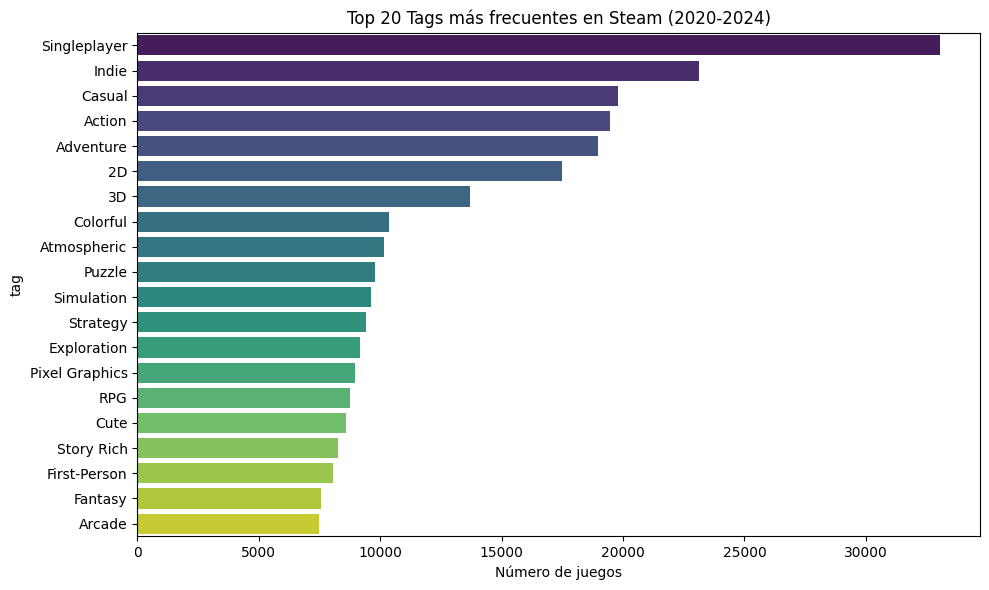

In [11]:
from collections import Counter

# Los tags vienen como dict {tag: peso}, extraemos solo los nombres
all_tags = []
for tags_dict in df_games['tags'].dropna():
    if isinstance(tags_dict, dict):
        all_tags.extend(tags_dict.keys())

tag_counts = Counter(all_tags).most_common(20)
tag_df = pd.DataFrame(tag_counts, columns=['tag', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=tag_df, x='count', y='tag', palette='viridis')
plt.title('Top 20 Tags más frecuentes en Steam (2020-2024)')
plt.xlabel('Número de juegos')
plt.tight_layout()
plt.show()


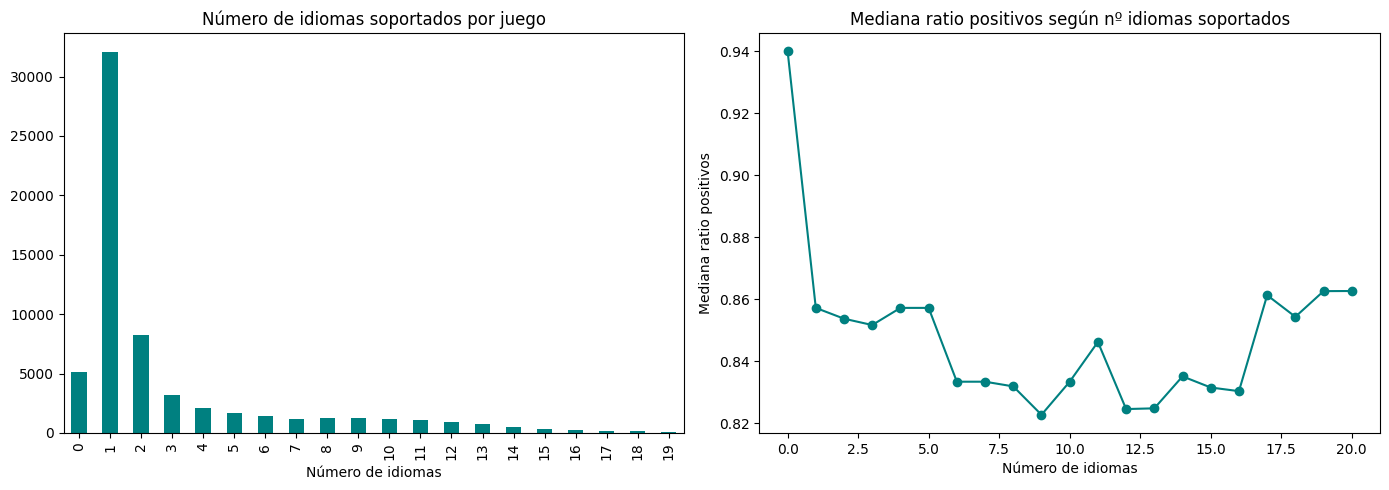


Top 10 idiomas más soportados:
English                57357
Simplified Chinese     18563
Japanese               15584
German                 14592
French                 14557
Russian                13753
Spanish - Spain        13646
Korean                 10252
Italian                 9927
Traditional Chinese     9614
dtype: int64


In [12]:
# Número de idiomas soportados por juego
df_games['num_languages'] = df_games['supported_languages'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del número de idiomas
df_games['num_languages'].value_counts().sort_index().head(20).plot(
    kind='bar', ax=axes[0], color='teal'
)
axes[0].set_title('Número de idiomas soportados por juego')
axes[0].set_xlabel('Número de idiomas')

# ¿Más idiomas = más éxito?
df_lang = df_games[df_games['total_votes'] >= 10]
lang_ratio = df_lang.groupby('num_languages')['positive_ratio'].median()
lang_ratio[lang_ratio.index <= 20].plot(kind='line', ax=axes[1], marker='o', color='teal')
axes[1].set_title('Mediana ratio positivos según nº idiomas soportados')
axes[1].set_xlabel('Número de idiomas')
axes[1].set_ylabel('Mediana ratio positivos')

plt.tight_layout()
plt.show()

print(f"\nTop 10 idiomas más soportados:")
all_langs = []
for langs in df_games['supported_languages'].dropna():
    if isinstance(langs, list):
        all_langs.extend(langs)
lang_counter = Counter(all_langs)
print(pd.Series(dict(lang_counter.most_common(10))))


In [13]:
print("=== OUTLIERS EN PRECIO ===")
print(df_games[df_games['price'] > 60][['name','price']].sort_values('price', ascending=False).head(10))

print("\n=== JUEGOS CON RATIO DE NEGATIVOS MUY ALTO (posible review bombing) ===")
df_bombing = df_games[
    (df_games['total_votes'] >= 50) & 
    (df_games['positive_ratio'] < 0.20)
][['name', 'positive', 'negative', 'positive_ratio']].sort_values('positive_ratio').head(10)
print(df_bombing)

print("\n=== JUEGOS CON PLAYTIME = 0 PERO MUCHOS VOTOS (anomalía) ===")
df_anomaly = df_games[
    (df_games['average_playtime_forever'] == 0) & 
    (df_games['total_votes'] >= 100)
][['name', 'average_playtime_forever', 'total_votes', 'positive_ratio']].head(10)
print(df_anomaly)


=== OUTLIERS EN PRECIO ===
                                     name   price
21108  The Leverage Game Business Edition  999.98
33136                   The Leverage Game  999.98
12541                           True Love  500.00
12571               Aartform Curvy 3D 4.0  299.99
64235         VEGAS Edit 20 Steam Edition  249.00
64822                        COINS BATTLE  199.99
64445                   Impossible Stunts  199.99
61708     Hidden Breaking Bed Top-Down 3D  199.99
64636                           灰烬行星与填鸭少女  199.99
164                            Destroy It  199.99

=== JUEGOS CON RATIO DE NEGATIVOS MUY ALTO (posible review bombing) ===
                           name  positive  negative  positive_ratio
785                SuperPower 3       122      1063        0.102954
189                    Only Up!        25       186        0.118483
23246  Sons Of The Dream Forest        10        65        0.133333
6669                      校长模拟器        13        69        0.158537
26820     

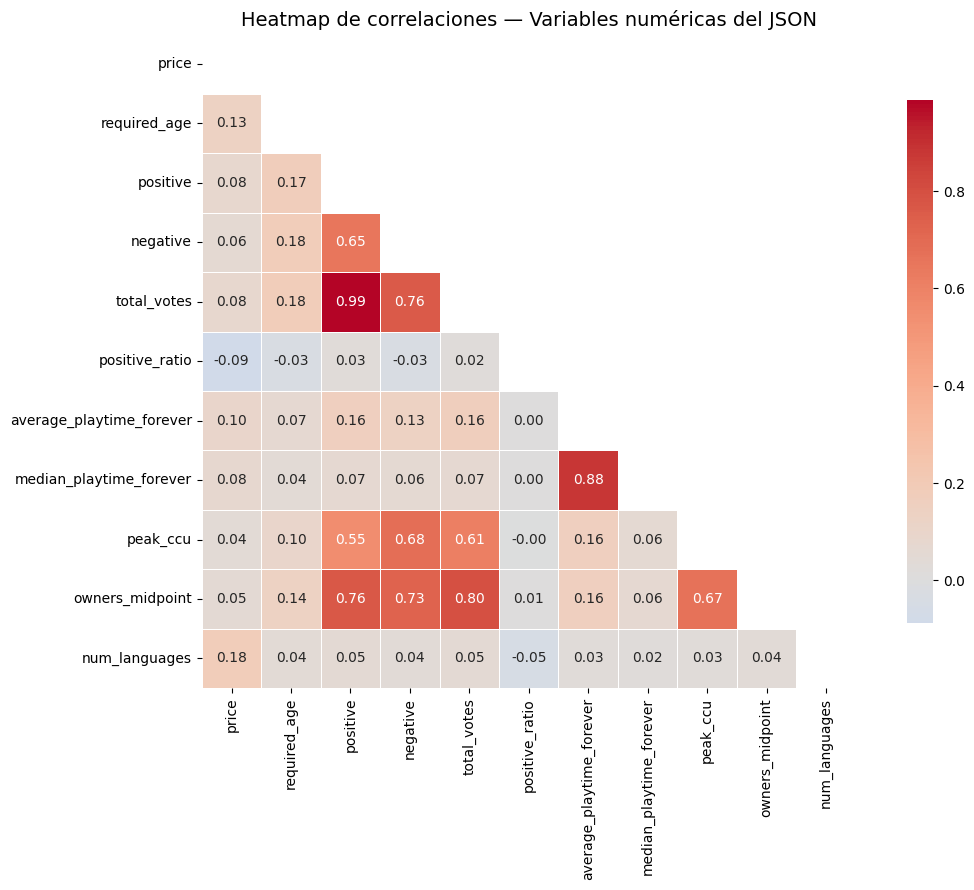

=== CORRELACIONES CON positive_ratio ===
positive                    0.030633
total_votes                 0.020367
owners_midpoint             0.006350
average_playtime_forever    0.004163
median_playtime_forever     0.001728
peak_ccu                   -0.001001
negative                   -0.028838
required_age               -0.030894
num_languages              -0.046698
price                      -0.087246
Name: positive_ratio, dtype: float64


In [14]:
# Seleccionar solo variables numéricas relevantes para el modelo
cols_corr = [
    'price', 'required_age', 'positive', 'negative', 'total_votes',
    'positive_ratio', 'average_playtime_forever', 'median_playtime_forever',
    'peak_ccu', 'owners_midpoint', 'num_languages'
]

# Filtrar columnas que existen
cols_corr = [c for c in cols_corr if c in df_games.columns]

# Solo juegos con al menos 10 votos para que positive_ratio sea significativo
df_corr = df_games[df_games['total_votes'] >= 10][cols_corr].copy()

plt.figure(figsize=(12, 9))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap de correlaciones — Variables numéricas del JSON', fontsize=14)
plt.tight_layout()
plt.show()

# Las 5 correlaciones más fuertes con positive_ratio (las más relevantes para el modelo)
print("=== CORRELACIONES CON positive_ratio ===")
print(corr_matrix['positive_ratio'].sort_values(ascending=False).drop('positive_ratio'))


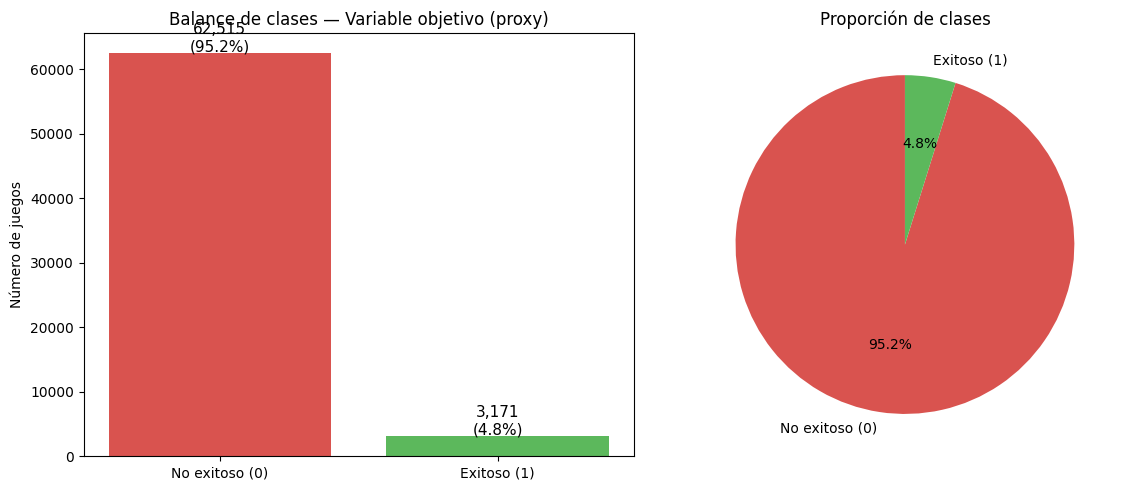


Ratio de desbalance: 19.7:1 (no exitosos vs exitosos)

  Nota: Este balance es una aproximación con votos del JSON.
   El balance real se calculará con los CSV de reseñas y filtro temporal T+180 días.


In [15]:
# Vista previa del desbalance de clases con los umbrales 100 votos / 90% positivos
# (Recordatorio: esto es aproximación con votos del JSON, no con reseñas reales)
df_games['is_successful_proxy'] = (
    (df_games['total_votes'] >= 100) & 
    (df_games['positive_ratio'] >= 0.90)
).astype(int)

conteo = df_games['is_successful_proxy'].value_counts()
porcentajes = df_games['is_successful_proxy'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(['No exitoso (0)', 'Exitoso (1)'], conteo.values, color=['#d9534f', '#5cb85c'])
for i, (v, p) in enumerate(zip(conteo.values, porcentajes.values)):
    axes[0].text(i, v + 200, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Balance de clases — Variable objetivo (proxy)')
axes[0].set_ylabel('Número de juegos')

# Pie chart
axes[1].pie(conteo.values, labels=['No exitoso (0)', 'Exitoso (1)'], 
            colors=['#d9534f', '#5cb85c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

print(f"\nRatio de desbalance: {conteo[0]/conteo[1]:.1f}:1 (no exitosos vs exitosos)")
print("\n  Nota: Este balance es una aproximación con votos del JSON.")
print("   El balance real se calculará con los CSV de reseñas y filtro temporal T+180 días.")


## Bloque A: JSON Videojuegos Steam
### 1. Calidad del dataset
- El JSON contiene **65.686 juegos** de Steam (2020–2024) **sin valores nulos**.
- Se detecta una anomalía: **13.521 juegos con "0 - 0" en `estimated_owners`**,
  probablemente juegos sin jugadores registrados o con privacidad activada.
  Serán tratados como categoría independiente en el modelado.
- **`average_playtime_forever = 0`** en el 94,7% de los juegos: Steam no registra
  playtime para títulos con muy pocos jugadores. Esta variable tiene utilidad
  limitada como feature y se usará con cautela.

### 2. Distribución temporal
- Los lanzamientos muestran **crecimiento año a año** (2020: ~9.000 → 2024: ~17.800),
  confirmando la saturación progresiva del catálogo de Steam.
- **Octubre es el mes con más lanzamientos**

### 3. Distribución de precios
- El **77,2% de los juegos son de pago** y el 22,8% gratuitos.
- Alta concentración en precios bajos (4,99€ - 9,99€), típico del mercado indie.
- Se detectan outliers de precio extremo (hasta 999,98€) correspondientes a
  software profesional (herramientas de diseño, edición) que serán filtrados
  o tratados como categoría especial en la limpieza.

### 4. Popularidad y engagement
- El **82,3% de los juegos tienen `peak_ccu = 0`**: la inmensa mayoría del catálogo
  de Steam son juegos "invisibles" que nunca han tenido impacto en streaming o CCU.
- Los juegos de pago tienen mayor mediana de ratio positivos (0.85) que los
  gratuitos (0.81), posiblemente porque los jugadores de pago tienen mayor
  compromiso previo con el título.

### 5. Estructura de géneros y tags
- **Indie** domina (~42.000 juegos), seguido de Casual, Adventure y Action.
  Los tags son más granulares y útiles como features que los géneros:
  `Singleplayer`, `Indie`, `Casual` y `Action` encabezan el Top 20.
- **Massively Multiplayer** es el género con peor mediana de ratio positivos (~0.70),
  posiblemente por las altas expectativas de los jugadores online y los problemas
  de servidores frecuentes en este género.

### 6. Correlaciones — Hallazgo crítico
- Las variables numéricas del JSON **no correlacionan con `positive_ratio`**
  (máx. correlación: 0.09 en valor absoluto). Esto demuestra que la calidad
  percibida de un videojuego **no es explicable por sus metadatos superficiales**
  (precio, edad requerida, número de idiomas), sino por señales más profundas
  contenidas en el **texto de las reseñas**, justificando el uso de NLP en este TFM.
- Alta multicolinealidad detectada entre `positive`/`total_votes` (0.99) y
  `average_playtime`/`median_playtime` (0.88). Se eliminará una variable de
  cada par en la fase de preprocesamiento para ML.

### 7. Variable objetivo (proxy) y desbalance de clases
- Con el umbral definido (≥100 votos y ≥90% positivos), solo el **4,8% de los
  juegos se clasifican como "exitosos"**, con un ratio de desbalance de **19.7:1**.
-  Este desbalance severo invalida la **accuracy** como métrica principal.
  El modelado utilizará **F1-Score, ROC-AUC y Precision-Recall AUC** como métricas
  primarias, y se aplicará `class_weight='balanced'` o SMOTE para compensar el
  desbalance en el entrenamiento.
-  Estos valores son una **aproximación con votos del JSON** (sin granularidad
  temporal). La variable objetivo definitiva se construirá a partir de los CSV de
  reseñas con filtro temporal T+180 días.


# Bloque B: CSV Reviews Steam

In [16]:
import os
import random

REVIEWS_DIR = '../data/raw/reviews/'  # Ajusta tu ruta

all_csvs = [f for f in os.listdir(REVIEWS_DIR) if f.endswith('.csv')]
print(f"Total de archivos CSV de reseñas: {len(all_csvs)}")

# Muestra aleatoria de 50 CSVs para exploración
random.seed(42)  # Reproducibilidad
sample_csvs = random.sample(all_csvs, min(50, len(all_csvs)))

dfs = []
for csv in sample_csvs:
    try:
        df = pd.read_csv(
            os.path.join(REVIEWS_DIR, csv),
            encoding='utf-8',
            encoding_errors='replace'
        )
        df['appid'] = csv.split('_')[0]
        df['source_file'] = csv
        dfs.append(df)
    except Exception as e:
        print(f"Error en {csv}: {e}")

df_reviews = pd.concat(dfs, ignore_index=True)

print(f"\nReseñas cargadas en la muestra: {len(df_reviews):,}")
print(f"Columnas: {df_reviews.columns.tolist()}")
print(f"\n--- Primeras 3 filas ---")
print(df_reviews.head(3))


Total de archivos CSV de reseñas: 23107

Reseñas cargadas en la muestra: 101,920
Columnas: ['user', 'playtime', 'post_date', 'helpfulness', 'review', 'recommend', 'early_access_review', 'appid', 'source_file']

--- Primeras 3 filas ---
        user  playtime          post_date  helpfulness  \
0  💜 † e e 💜       4.1      June 22, 2024            8   
1   zazabuza       0.9  September 1, 2024            1   
2   Rezuverk       2.9     August 5, 2024            1   

                                              review        recommend  \
0  Fierce battles in the arena of little colored ...      Recommended   
1  Falta muito pra esse jogo ser pelo menos jogáv...  Not Recommended   
2  Ожесточенные сражения на арене, цель одолеть с...      Recommended   

  early_access_review    appid     source_file  
0                 NaN  3032660  3032660_73.csv  
1                 NaN  3032660  3032660_73.csv  
2                 NaN  3032660  3032660_73.csv  


In [17]:
print("=== TIPOS DE DATOS ===")
print(df_reviews.dtypes)

print("\n=== VALORES NULOS ===")
nulos = df_reviews.isnull().sum()
nulos_pct = (nulos / len(df_reviews) * 100).round(2)
resumen = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct})
print(resumen[resumen['nulos'] > 0].sort_values('pct', ascending=False))


=== TIPOS DE DATOS ===
user                       str
playtime               float64
post_date                  str
helpfulness              int64
review                     str
recommend                  str
early_access_review     object
appid                      str
source_file                str
dtype: object

=== VALORES NULOS ===
                     nulos    pct
early_access_review  99746  97.87
review                 338   0.33
user                     9   0.01


=== DISTRIBUCIÓN DE recommend ===
recommend
Recommended        68477
Not Recommended    33443
Name: count, dtype: int64

Ratio Recommended/Not Recommended: 2.05:1


C:\Users\longm\AppData\Local\Temp\ipykernel_12240\3124932509.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recommend_counts.index, y=recommend_counts.values, palette=['#5cb85c', '#d9534f'])


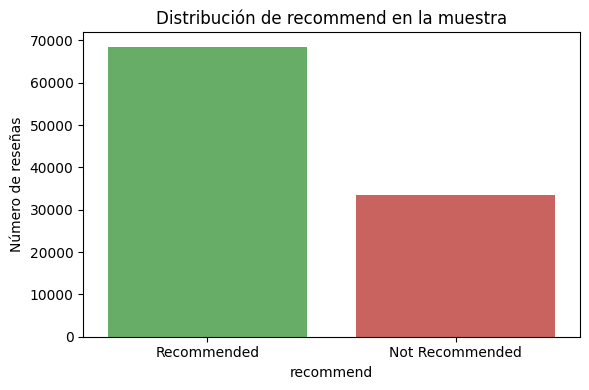

In [18]:
recommend_counts = df_reviews['recommend'].value_counts()
print("=== DISTRIBUCIÓN DE recommend ===")
print(recommend_counts)
print(f"\nRatio Recommended/Not Recommended: {recommend_counts.iloc[0]/recommend_counts.iloc[1]:.2f}:1")

plt.figure(figsize=(6, 4))
sns.barplot(x=recommend_counts.index, y=recommend_counts.values, palette=['#5cb85c', '#d9534f'])
plt.title('Distribución de recommend en la muestra')
plt.ylabel('Número de reseñas')
plt.tight_layout()
plt.show()


Fechas no parseables: 0

Rango de fechas:
  Más antigua: 2018-10-11 00:00:00
  Más reciente: 2024-12-03 00:00:00

=== DISTRIBUCIÓN POR AÑO ===
review_year
2018       36
2019      107
2020     2336
2021    13359
2022     7930
2023    49906
2024    28246
Name: count, dtype: int64


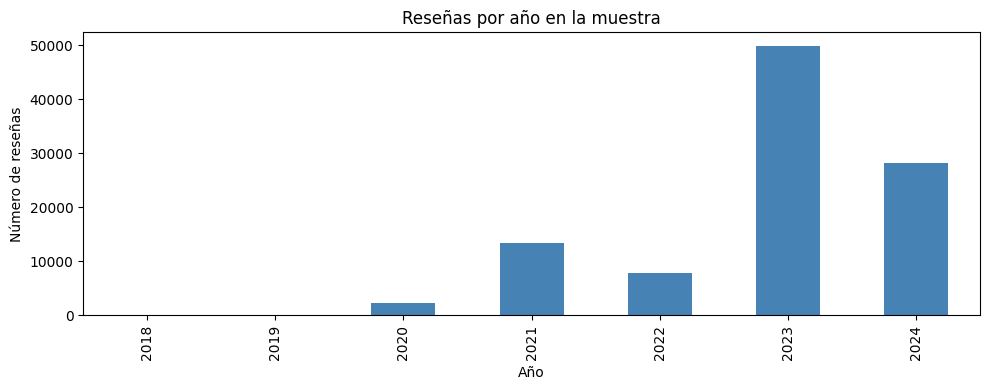

In [19]:
# Convertir post_date a datetime
df_reviews['post_date_parsed'] = pd.to_datetime(df_reviews['post_date'], format='mixed', errors='coerce')
df_reviews['review_year'] = df_reviews['post_date_parsed'].dt.year
df_reviews['review_month'] = df_reviews['post_date_parsed'].dt.month

print(f"Fechas no parseables: {df_reviews['post_date_parsed'].isna().sum()}")
print(f"\nRango de fechas:")
print(f"  Más antigua: {df_reviews['post_date_parsed'].min()}")
print(f"  Más reciente: {df_reviews['post_date_parsed'].max()}")

print(f"\n=== DISTRIBUCIÓN POR AÑO ===")
print(df_reviews['review_year'].value_counts().sort_index())

plt.figure(figsize=(10, 4))
df_reviews['review_year'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Reseñas por año en la muestra')
plt.xlabel('Año')
plt.ylabel('Número de reseñas')
plt.tight_layout()
plt.show()


C:\Users\longm\AppData\Local\Temp\ipykernel_12240\63608634.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_reviews[df_reviews['review_len_words'] < p99],


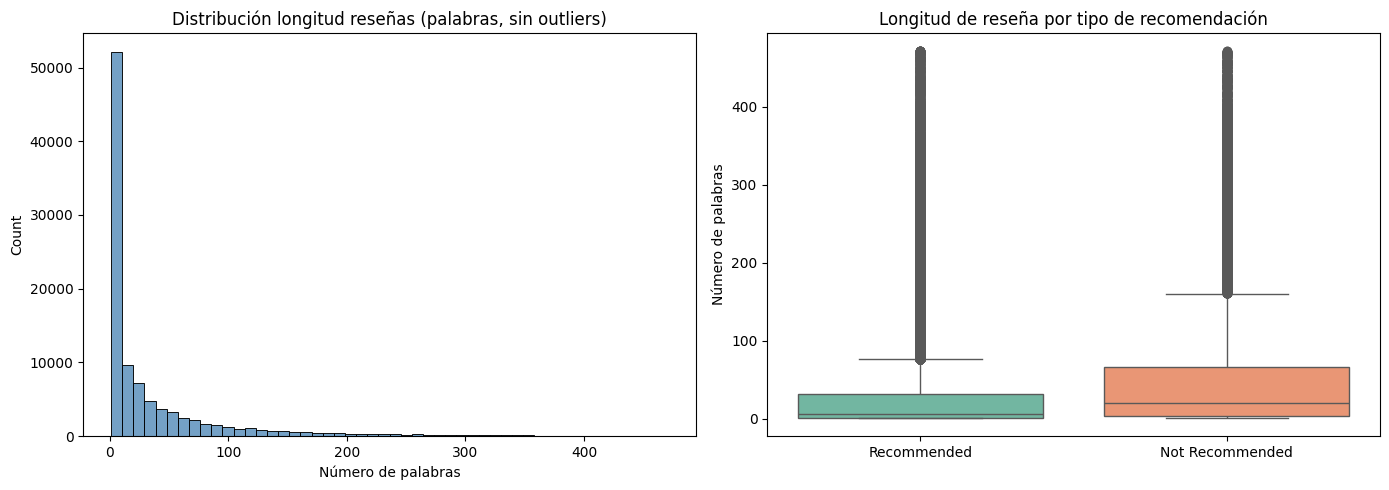

=== ESTADÍSTICAS DE LONGITUD (palabras) ===
                   count       mean         std  min  25%   50%   75%     max
recommend                                                                    
Not Recommended  33389.0  62.551349  117.897776  1.0  3.0  21.0  70.0  1563.0
Recommended      68193.0  35.352412   84.230109  1.0  1.0   6.0  32.0  1503.0


In [20]:
# Longitud en caracteres y palabras
df_reviews['review_len_chars'] = df_reviews['review'].astype(str).str.len()
df_reviews['review_len_words'] = df_reviews['review'].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de longitud en palabras (sin outliers extremos)
p99 = df_reviews['review_len_words'].quantile(0.99)
sns.histplot(df_reviews[df_reviews['review_len_words'] < p99]['review_len_words'], 
             bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución longitud reseñas (palabras, sin outliers)')
axes[0].set_xlabel('Número de palabras')

# Boxplot por tipo de recomendación
sns.boxplot(data=df_reviews[df_reviews['review_len_words'] < p99], 
            x='recommend', y='review_len_words', ax=axes[1], palette='Set2')
axes[1].set_title('Longitud de reseña por tipo de recomendación')
axes[1].set_xlabel('')
axes[1].set_ylabel('Número de palabras')

plt.tight_layout()
plt.show()

print("=== ESTADÍSTICAS DE LONGITUD (palabras) ===")
print(df_reviews.groupby('recommend')['review_len_words'].describe())


=== ESTADÍSTICAS DE helpfulness ===
count    101920.000000
mean          4.201069
std          59.022446
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        8793.000000
Name: helpfulness, dtype: float64


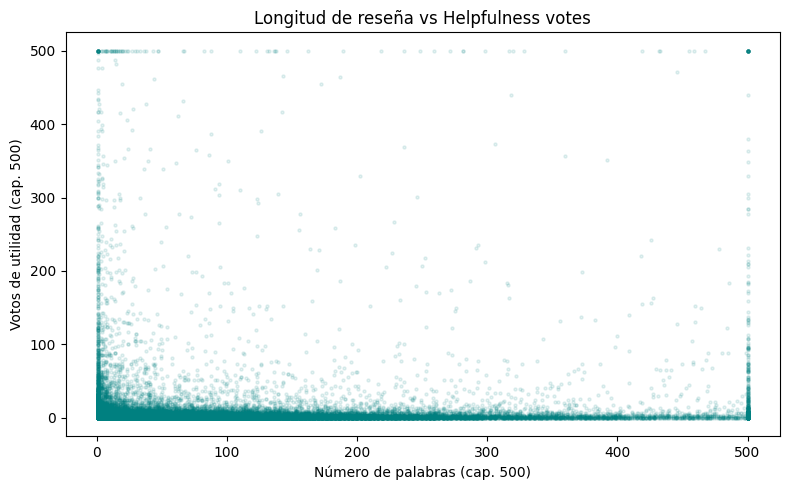

In [21]:
print("=== ESTADÍSTICAS DE helpfulness ===")
print(df_reviews['helpfulness'].describe())

# ¿Las reseñas más largas son más útiles?
df_help = df_reviews[df_reviews['helpfulness'] >= 0].copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    df_help['review_len_words'].clip(upper=500), 
    df_help['helpfulness'].clip(upper=500),
    alpha=0.1, s=5, color='teal'
)
plt.title('Longitud de reseña vs Helpfulness votes')
plt.xlabel('Número de palabras (cap. 500)')
plt.ylabel('Votos de utilidad (cap. 500)')
plt.tight_layout()
plt.show()


=== RESEÑAS POR JUEGO EN LA MUESTRA ===
count       50.000000
mean      2038.400000
std       8925.800365
min         28.000000
25%         50.250000
50%        118.500000
75%        480.000000
max      62220.000000
dtype: float64


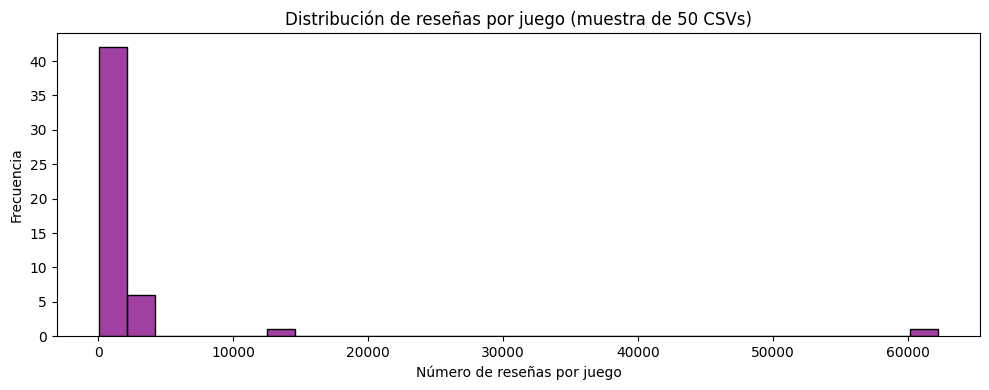


=== VERIFICACIÓN: reseñas reales vs nombre del CSV ===
3032660_73.csv: esperadas=73, cargadas=73
1318970_151.csv: esperadas=151, cargadas=151
1121590_210.csv: esperadas=210, cargadas=210
1683380_127.csv: esperadas=127, cargadas=127
1608110_65.csv: esperadas=65, cargadas=65


In [22]:
reviews_per_game = df_reviews.groupby('appid').size().sort_values(ascending=False)

print("=== RESEÑAS POR JUEGO EN LA MUESTRA ===")
print(reviews_per_game.describe())

plt.figure(figsize=(10, 4))
sns.histplot(reviews_per_game, bins=30, color='purple')
plt.title('Distribución de reseñas por juego (muestra de 50 CSVs)')
plt.xlabel('Número de reseñas por juego')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Verificar que el número de reseñas del CSV coincide con el nombre del archivo
print("\n=== VERIFICACIÓN: reseñas reales vs nombre del CSV ===")
for csv in sample_csvs[:5]:
    expected = int(csv.split('_')[1].replace('.csv', ''))
    appid = csv.split('_')[0]
    actual = len(df_reviews[df_reviews['appid'] == appid])
    print(f"{csv}: esperadas={expected}, cargadas={actual}")


In [23]:
print("=== MUESTRA DE TEXTOS DE RESEÑAS ===\n")

# Mostrar 5 reseñas aleatorias para ver diversidad de idiomas y contenido
sample_reviews = df_reviews[df_reviews['review_len_words'] > 5].sample(8, random_state=42)
for _, row in sample_reviews.iterrows():
    print(f"AppID: {row['appid']} | Recommend: {row['recommend']} | Palabras: {row['review_len_words']}")
    print(f"Texto: {str(row['review'])[:200]}...")
    print("-" * 60)


=== MUESTRA DE TEXTOS DE RESEÑAS ===

AppID: 949230 | Recommend: Recommended | Palabras: 123.0
Texto: Although the optimization still needs a decent amount of work and the game shouldn't have been released this early, the building blocks to make this game incredible are most definitely there. Even if ...
------------------------------------------------------------
AppID: 2505120 | Recommend: Recommended | Palabras: 117.0
Texto: i luv luv luv LUV this game so much!!! started playin on stream a couple of days ago and m completely obsessed.true to the title, this game is therapeutic and i felt so eased and happy while playing. ...
------------------------------------------------------------
AppID: 949230 | Recommend: Not Recommended | Palabras: 16.0
Texto: CRASH ALWAYS!!! refund MEEEE!!!UPdate 29/08/2024game now go but wait more update for very like and UP...
------------------------------------------------------------
AppID: 949230 | Recommend: Not Recommended | Palabras: 15.0
Texto: Die

In [24]:
# Cuántas reseñas tienen texto vacío o muy corto (< 3 palabras)
df_reviews['is_very_short'] = df_reviews['review_len_words'] < 3

print("=== RESEÑAS MUY CORTAS (< 3 palabras) ===")
print(f"Total: {df_reviews['is_very_short'].sum():,} ({df_reviews['is_very_short'].mean()*100:.1f}%)")

# Muestras de reseñas muy cortas
print("\nEjemplos de reseñas muy cortas:")
print(df_reviews[df_reviews['is_very_short']]['review'].dropna().head(10).tolist())

# Cuántas reseñas tienen NaN en review
print(f"\nReseñas con texto NaN: {df_reviews['review'].isna().sum()}")

# ¿Qué porcentaje de las reseñas early_access tiene contenido?
print(f"\nReseñas de Early Access: {df_reviews['early_access_review'].notna().sum():,} ({df_reviews['early_access_review'].notna().mean()*100:.2f}%)")


=== RESEÑAS MUY CORTAS (< 3 palabras) ===
Total: 35,961 (35.3%)

Ejemplos de reseñas muy cortas:
['Unity製だがXUnity.AutoTranslatorは機能しなかった。AutoTranslatorフォルダは作られるが翻訳もフォントの置き換えもされない。ゲームを開始するとシェークスピアを名乗る男が挨拶をする。シェークスピアの作品世界に4人組の女性がポータルを抜けて現れ、唐突にセーラームーンモドキに変身して村をウロついている怪物と戦うという、よくわからない設定。キャラ絵は可愛いしコマンド式戦闘のRPGで無難に遊べるゲームに思えるが、日本語対応していないので続ける気にならない。せめてXUnity.AutoTranslatorが機能すれば良かったのだが。', 'Cringe', 'Totally rad.', '日本語非対応なのでゲーム中のヒントがわかりづらい部分もありますが下記の事さえ覚えておけば、ゲーム進行にはさほど支障は無いと思います（暗闇を進むには右クリックでカメラを構え左クリックでフラッシュ）落下死や、敵に追われることはないので実質ゲームオーバーはありません時々不気味なモノが見えますが害は無いのでびっくりポイント重視のホラーゲームゲーム中に移動時に画面が揺れますので画面揺れに弱い方は購入を考えた方がよさそうです雰囲気は非常によいゲームなのですが、バグにより進行不可になってしまい断念現状定価には見合わないので、セールを待って買うのがよいでしょうYOUTUBEに動画をUPさせて頂きました。参考になれば幸いです', '没英文，没新手引导，还有我老是闪退', '画面很好，优化还不错，精神无人系的游戏。属于作者精神病人思路广的类型，然后我卡关了mmp！', '무쉅진않눼', '糟糕的动态模糊屎一样的操作没有手电筒 毫无逻辑的解谜成就了这一坨大粪', '这是一款恐怖解谜游戏。看到游戏介绍，我去google了一下，原来这款游戏与作者童年的经历有关。童年的创伤导致长大后依然有挥之不去的阴影。这里祝愿作者早日走出阴影，回归到正常的生活。游戏没有基本操作的介绍，这里简单的说一下：E键互动，Tab键查看物品，空格键跳跃，Ctrl键蹲下，鼠标左键捡起物品或者按着不放可以拖动物品，鼠标

In [25]:
# Estimar volumen total basándonos en los nombres de los CSVs
total_reviews_estimated = sum(
    int(f.split('_')[1].replace('.csv', '')) 
    for f in all_csvs 
    if len(f.split('_')) == 2
)

print("=== ESTIMACIÓN DEL VOLUMEN TOTAL ===")
print(f"Total CSVs (juegos con reseñas): {len(all_csvs):,}")
print(f"Total reseñas estimadas (suma de nombres de archivos): {total_reviews_estimated:,}")
print(f"Media de reseñas por juego: {total_reviews_estimated/len(all_csvs):,.0f}")

# Distribución del tamaño de los archivos por nombre
review_counts_all = [
    int(f.split('_')[1].replace('.csv', '')) 
    for f in all_csvs 
    if len(f.split('_')) == 2
]
review_counts_series = pd.Series(review_counts_all)

print(f"\nDistribución de reseñas por juego (todos los CSVs):")
print(review_counts_series.describe())
print(f"\nJuegos con < 100 reseñas: {(review_counts_series < 100).sum():,} ({(review_counts_series < 100).mean()*100:.1f}%)")
print(f"Juegos con >= 1.000 reseñas: {(review_counts_series >= 1000).sum():,} ({(review_counts_series >= 1000).mean()*100:.1f}%)")
print(f"Juegos con >= 10.000 reseñas: {(review_counts_series >= 10000).sum():,} ({(review_counts_series >= 10000).mean()*100:.1f}%)")


=== ESTIMACIÓN DEL VOLUMEN TOTAL ===
Total CSVs (juegos con reseñas): 23,107
Total reseñas estimadas (suma de nombres de archivos): 31,832,390
Media de reseñas por juego: 1,378

Distribución de reseñas por juego (todos los CSVs):
count     23107.000000
mean       1377.608084
std        8349.501062
min          26.000000
25%          45.000000
50%         100.000000
75%         367.000000
max      336460.000000
dtype: float64

Juegos con < 100 reseñas: 11,531 (49.9%)
Juegos con >= 1.000 reseñas: 3,226 (14.0%)
Juegos con >= 10.000 reseñas: 617 (2.7%)


## Bloque B: EDA de CSV de Reseñas 

### 1. Estructura del dataset de reseñas
- **23.107 archivos CSV** con un total estimado de **31.832.390 reseñas**.
- Columnas disponibles: `user`, `playtime`, `post_date`, `helpfulness`,
  `review`, `recommend`, `early_access_review`.
-  **Ausencia de columna `language`**: el scraper no registró el idioma
  de cada reseña. La detección de idioma se realizará en la fase de limpieza
  mediante análisis de caracteres o modelos multilingües directamente.

### 2. Calidad del texto
- **35,3% de reseñas aparentemente cortas (< 3 palabras)**: este porcentaje
  está inflado artificialmente porque el tokenizador por espacios (`split()`)
  no funciona con idiomas CJK (chino, japonés, coreano), que no usan espacios
  entre palabras. El filtro real de limpieza se basará en **número de caracteres
  (< 10)** para detectar reseñas vacías o spam.
- **338 reseñas con texto NaN** (0,33%): serán eliminadas en la limpieza.
- Se detecta contenido spam/off-topic. Se aplicará un filtro mínimo de contenido por longitud.

### 3. Distribución temporal
- Rango de fechas: **octubre 2018 – diciembre 2024**.
- Presencia de reseñas pre-2020 (2018: 36, 2019: 107) procedentes de juegos
  en Early Access antes de su lanzamiento oficial. Serán evaluadas en la
  limpieza para decidir si se retienen o filtran.
- El **año 2023 concentra el mayor volumen** de reseñas en la muestra (~49.900),
  coherente con el mayor número de lanzamientos ese año detectado en el JSON.

### 4. Patrones de comportamiento del usuario
- **Ratio Recommended/Not Recommended: ~2:1** (67% positivas, 33% negativas).
- Las reseñas negativas son significativamente **más largas** que las positivas
  (mediana 21 vs 6 palabras en idiomas occidentales): los jugadores insatisfechos
  tienden a argumentar más su posición. Esta asimetría será una **feature NLP**
  relevante (`review_len_chars` como proxy universal válido para todos los idiomas).
- `helpfulness` está muy sesgado: mediana = 0, 75% ≤ 1 voto. Solo una élite
  de reseñas tiene alta utilidad percibida, lo que refuerza la estrategia de
  submuestreo por `helpfulness` para reducir el volumen a procesar.

### 5. Distribución de volumen por juego
- **49,9% de los juegos tienen < 100 reseñas**: estos títulos serán **excluidos
  del modelado** al no alcanzar el umbral mínimo para que la variable objetivo
  sea estadísticamente representativa (criterio consistente con el propio
  dataset original, que ya descartó juegos con < 25 reseñas).
- Solo el **2,7% de los juegos (617 títulos) tienen ≥ 10.000 reseñas**,
  confirmando la distribución de larga cola característica del mercado de
  videojuegos de Steam.

### 6. Decisiones metodológicas derivadas del EDA
| Decisión | Criterio | Justificación |
|---|---|---|
| Filtro mínimo de reseñas | ≥ 100 reseñas por juego | Umbral estadístico para variable objetivo |
| Filtro de texto vacío | < 10 caracteres → eliminar | Válido para todos los idiomas incluyendo CJK |
| `early_access_review` | Eliminar columna | 97,87% nulos, sin valor predictivo |
| Detección de idioma | Por caracteres o modelo multilingüe | Ausencia de columna `language` en el scraper |
| Submuestreo | Top N reseñas por `helpfulness` | Reducir 31M a volumen manejable manteniendo calidad |


# Bloque C: Datos de Twitch


In [26]:
df_twitch = pd.read_csv('../data/raw/Twitch_game_data.csv', encoding='latin1')

print(f"Shape: {df_twitch.shape}")
print(f"\nColumnas: {df_twitch.columns.tolist()}")
print(f"\nPrimeras 3 filas:")
print(df_twitch.head(3))
print(f"\n=== TIPOS DE DATOS ===")
print(df_twitch.dtypes)
print(f"\n=== VALORES NULOS ===")
nulos = df_twitch.isnull().sum()
print(nulos[nulos > 0])


Shape: (21000, 12)

Columnas: ['Rank', 'Game', 'Month', 'Year', 'Hours_watched', 'Hours_streamed', 'Peak_viewers', 'Peak_channels', 'Streamers', 'Avg_viewers', 'Avg_channels', 'Avg_viewer_ratio']

Primeras 3 filas:
   Rank                              Game  Month  Year  Hours_watched  \
0     1                 League of Legends      1  2016       94377226   
1     2  Counter-Strike: Global Offensive      1  2016       47832863   
2     3                            Dota 2      1  2016       45185893   

   Hours_streamed  Peak_viewers  Peak_channels  Streamers  Avg_viewers  \
0         1362044        530270           2903     129172       127021   
1          830105        372654           2197     120849        64378   
2          433397        315083           1100      44074        60815   

   Avg_channels  Avg_viewer_ratio  
0          1833             69.29  
1          1117             57.62  
2           583            104.26  

=== TIPOS DE DATOS ===
Rank                  int64

In [27]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df_twitch.describe())

# ¿Cuántos juegos únicos hay?
# Buscar columna de nombre del juego (puede llamarse 'Game', 'game', 'Name'...)
col_game = [c for c in df_twitch.columns if 'game' in c.lower() or 'name' in c.lower()]
print(f"\nColumnas candidatas a nombre de juego: {col_game}")

if col_game:
    print(f"\nJuegos únicos: {df_twitch[col_game[0]].nunique():,}")
    print(f"\nTop 10 juegos más frecuentes:")
    print(df_twitch[col_game[0]].value_counts().head(10))


=== ESTADÍSTICAS DESCRIPTIVAS ===
              Rank         Month          Year  Hours_watched  Hours_streamed  \
count  21000.00000  21000.000000  21000.000000   2.100000e+04    2.100000e+04   
mean     100.50000      6.371429   2019.885714   5.831853e+06    1.900508e+05   
std       57.73568      3.412264      2.527300   1.943051e+07    5.702921e+05   
min        1.00000      1.000000   2016.000000   8.981100e+04    1.900000e+01   
25%       50.75000      3.000000   2018.000000   5.430898e+05    1.597150e+04   
50%      100.50000      6.000000   2020.000000   1.079297e+06    4.230250e+04   
75%      150.25000      9.000000   2022.000000   3.032041e+06    1.099875e+05   
max      200.00000     12.000000   2024.000000   3.445520e+08    1.024570e+07   

       Peak_viewers  Peak_channels     Streamers    Avg_viewers  Avg_channels  \
count  2.100000e+04   21000.000000  2.100000e+04   21000.000000  21000.000000   
mean   6.430924e+04     697.252524  2.365554e+04    7996.368762    260.118


Juegos únicos: 2,359

Top 10 juegos más frecuentes:
Game
Dungeons & Dragons       106
Retro                    106
League of Legends        105
Dota 2                   105
Hearthstone              105
Minecraft                105
World of Warcraft        105
Talk Shows & Podcasts    105
StarCraft II             105
World of Tanks           105
Name: count, dtype: int64


In [28]:
# Buscar columna de fecha
col_date = [c for c in df_twitch.columns if 'date' in c.lower() or 'month' in c.lower() or 'year' in c.lower()]
print(f"Columnas de fecha detectadas: {col_date}")

# Buscar columnas de métricas de audiencia
col_metrics = [c for c in df_twitch.columns if any(
    x in c.lower() for x in ['viewer', 'stream', 'hour', 'peak', 'watch', 'channel']
)]
print(f"Columnas de métricas: {col_metrics}")

if col_metrics:
    print(f"\n=== ESTADÍSTICAS DE MÉTRICAS DE AUDIENCIA ===")
    print(df_twitch[col_metrics].describe())


Columnas de fecha detectadas: ['Month', 'Year']
Columnas de métricas: ['Hours_watched', 'Hours_streamed', 'Peak_viewers', 'Peak_channels', 'Streamers', 'Avg_viewers', 'Avg_channels', 'Avg_viewer_ratio']

=== ESTADÍSTICAS DE MÉTRICAS DE AUDIENCIA ===
       Hours_watched  Hours_streamed  Peak_viewers  Peak_channels  \
count   2.100000e+04    2.100000e+04  2.100000e+04   21000.000000   
mean    5.831853e+06    1.900508e+05  6.430924e+04     697.252524   
std     1.943051e+07    5.702921e+05  1.554388e+05    2652.329931   
min     8.981100e+04    1.900000e+01  4.410000e+02       1.000000   
25%     5.430898e+05    1.597150e+04  1.004825e+04      66.000000   
50%     1.079297e+06    4.230250e+04  2.345950e+04     158.000000   
75%     3.032041e+06    1.099875e+05  5.519000e+04     403.000000   
max     3.445520e+08    1.024570e+07  3.915488e+06  129860.000000   

          Streamers    Avg_viewers  Avg_channels  Avg_viewer_ratio  
count  2.100000e+04   21000.000000  21000.000000      21000

In [29]:
# El cruce con Steam se hará por nombre de juego (no hay appid en Twitch)
# Necesitamos ver qué formato tienen los nombres en Twitch vs Steam

if col_game:
    twitch_games = set(df_twitch[col_game[0]].dropna().str.lower().str.strip())
    steam_games = set(df_games['name'].dropna().str.lower().str.strip())
    
    matches = twitch_games.intersection(steam_games)
    
    print(f"Juegos únicos en Twitch: {len(twitch_games):,}")
    print(f"Juegos únicos en Steam (elegibles): {len(steam_games):,}")
    print(f"Matches exactos por nombre: {len(matches):,}")
    print(f"Porcentaje de Twitch cubierto: {len(matches)/len(twitch_games)*100:.1f}%")
    print(f"\nEjemplos de matches:")
    print(list(matches)[:10])
    print(f"\nEjemplos de juegos en Twitch sin match en Steam:")
    no_match = twitch_games - steam_games
    print(list(no_match)[:10])


Juegos únicos en Twitch: 2,334
Juegos únicos en Steam (elegibles): 65,205
Matches exactos por nombre: 617
Porcentaje de Twitch cubierto: 26.4%

Ejemplos de matches:
['legend of mortal', 'old school runescape', 'stumble guys', 'dungeonborne', 'nine sols', 'two point campus', 'hitman world of assassination', 'tormented souls', 'forza motorsport', 'a total war saga: troy']

Ejemplos de juegos en Twitch sin match en Steam:
['earthbound', 'the long drive', "marvel's spider-man remastered", 'nba 2k21', 'kirby: nightmare in dream land', 'exanima', 'minecraft', 'protocol', 'movie world', 'dark souls ii: scholar of the first sin']


In [34]:
# Filtrar Twitch solo desde 2020
df_twitch_filtered = df_twitch[df_twitch['Year'] >= 2020].copy()

df_twitch_filtered['game_normalized'] = (
    df_twitch_filtered['Game'].str.lower().str.strip()
    .str.replace(r'[^\w\s]', '', regex=True)
)

# ── CORRECCIÓN: usar df_games directamente sin df_eligible ──
steam_names = df_games[['appid', 'name']].copy()
steam_names['name_normalized'] = (
    steam_names['name'].str.lower().str.strip()
    .str.replace(r'[^\w\s]', '', regex=True)
)

twitch_games_2020 = set(df_twitch_filtered['game_normalized'].dropna())
steam_games_eligible = set(steam_names['name_normalized'].dropna())

matches_2020 = twitch_games_2020.intersection(steam_games_eligible)
print(f"Juegos Twitch desde 2020: {df_twitch_filtered['Game'].nunique():,}")
print(f"Matches tras normalización y filtro 2020+: {len(matches_2020):,}")
print(f"Cobertura sobre juegos de Steam: {len(matches_2020)/len(steam_games_eligible)*100:.1f}%")

print(f"\nEjemplos de matches encontrados:")
print(list(matches_2020)[:10])


Juegos Twitch desde 2020: 1,341
Matches tras normalización y filtro 2020+: 639
Cobertura sobre juegos de Steam: 1.0%

Ejemplos de matches encontrados:
['legend of mortal', 'old school runescape', 'stumble guys', 'dungeonborne', 'nine sols', 'two point campus', 'lost in random', 'hitman world of assassination', 'tormented souls', 'forza motorsport']


## EDA del Dataset de Twitch — Conclusiones

### 1. Estructura del dataset
- El dataset de Twitch contiene **21.000 registros** correspondientes al 
  **Top 200 de juegos más vistos mensualmente** en Twitch desde enero 2016 
  hasta diciembre 2024, con **12 variables** de audiencia.
- Solo **1 valor nulo** detectado en la columna `Game`, sin impacto relevante.

### 2. Cobertura temporal y juegos únicos
- El dataset cubre **9 años** (2016–2024), aunque solo los registros desde 
  2020 son relevantes para el cruce con Steam, reduciendo la cantidad de instancias a
  **1.341 juegos únicos** en el período de interés.
- La naturaleza del dataset (Top 200 mensual) implica que **solo los juegos 
  más populares de Twitch tienen representación**, quedando excluida la 
  inmensa mayoría del catálogo de Steam.

### 3. Problema de cruce con Steam
- Tras normalización de nombres (minúsculas, eliminación de puntuación), 
  el match exacto entre Twitch y Steam produce **639 juegos coincidentes**, 
  representando apenas el **1% del catálogo de Steam** y el **47,7% de los 
  juegos de Twitch desde 2020**.
- Los juegos sin match en Steam incluyen títulos multiplataforma 
  como (`Fortnite`, `Pokémon`) y juegos lanzados antes de 2020 que siguen 
  activos en Twitch, lo que explica la baja cobertura.
- Una cobertura del 1% sobre el catálogo de Steam **hace inviable usar 
  las métricas cuantitativas de Twitch** (horas vistas, viewers) como 
  features directas del modelo, ya que generaría ~99% de valores vacíos.

### 4. Decisión metodológica: Feature binaria de presencia en Twitch
- Dado el bajo porcentaje de cruce, las métricas de Twitch se integrarán 
  como una **única feature binaria**: `appeared_on_twitch_top200 = 1` si 
  el juego apareció alguna vez en el Top 200 de Twitch entre su fecha de 
  lanzamiento y T+180 días, `0` en caso contrario.
- Esta aproximación es metodológicamente sólida: la mera presencia en el 
  Top 200 de Twitch es un indicador de visibilidad excepcional y diferencia 
  claramente los juegos con tracción en streaming de los que no la tienen, 
  sin introducir el problema de imputación masiva de NaN.
- Para los 639 juegos con match, se calculará adicionalmente el 
  `peak_viewers_launch` (máximo de viewers en los primeros 30 días), 
  disponible como feature opcional para análisis de sensibilidad del modelo.


In [35]:
# ¿Hay appids duplicados en el JSON?
print(f"Total filas en df_games: {len(df_games):,}")
print(f"AppIDs únicos: {df_games['appid'].nunique():,}")
print(f"Duplicados: {df_games['appid'].duplicated().sum()}")

# ¿Cuántos juegos del JSON tienen CSV de reseñas?
csv_appids = set(f.split('_')[0] for f in os.listdir(REVIEWS_DIR) if f.endswith('.csv'))
games_with_reviews = df_games[df_games['appid'].isin(csv_appids)]
games_without_reviews = df_games[~df_games['appid'].isin(csv_appids)]

print(f"\nJuegos del JSON con CSV de reseñas: {len(games_with_reviews):,}")
print(f"Juegos del JSON SIN CSV de reseñas: {len(games_without_reviews):,}")
print(f"\nEjemplos de juegos SIN reseñas:")
print(games_without_reviews[['appid','name','positive','negative']].head(10))


Total filas en df_games: 65,686
AppIDs únicos: 65,686
Duplicados: 0

Juegos del JSON con CSV de reseñas: 23,107
Juegos del JSON SIN CSV de reseñas: 42,579

Ejemplos de juegos SIN reseñas:
      appid                                    name  positive  negative
1   2201840                         그녀가 다시 노래할 때까지.         8         2
2   1364180                Counter Operation Online         1         1
4   3262620                                  剑武玄幻之旅         8         2
6   1454110                Desolation - End of Days         2         1
8   1772160                  Nonlinear System Tools         2         1
9   2644700                              Impossible         1         0
10  2636570                                  Solune         4         1
13  1482940                  Rumours From Elsewhere        12         0
15  2061140  The Mangotronics Employment Collection         1         0
16  1613290                     Couplinked Playtest         0         0


In [36]:
# ¿Hay nombres duplicados con distinto AppID?
name_counts = df_games['name'].value_counts()
duplicated_names = name_counts[name_counts > 1]

print(f"Nombres que aparecen más de una vez: {len(duplicated_names)}")
print(f"\nTop 15 nombres duplicados:")
print(duplicated_names.head(15))

# Ver los casos concretos de los más duplicados
print(f"\nDetalle de los casos más duplicados:")
top_dup_name = duplicated_names.index[0]
print(df_games[df_games['name'] == top_dup_name][['appid', 'name', 'release_date', 'price', 'positive', 'negative']])


Nombres que aparecen más de una vez: 314

Top 15 nombres duplicados:
name
Loop                5
Zombie Hunter       4
EA SPORTS FC™ 24    4
Alone               4
EA SPORTS FC™ 25    4
Echoes              4
Dodge               3
Nightmare           3
Endless             3
Gravity             3
Hentai Nurse        3
Hero's Journey      3
The Island          3
Abyss               3
No Way Out          3
Name: count, dtype: int64

Detalle de los casos más duplicados:
         appid  name  release_date  price  positive  negative
1617   3233970  Loop   Oct 8, 2024   4.99         2         2
13576  2365200  Loop  Jun 25, 2023   0.00         0         0
26469  1460290  Loop  Nov 24, 2020   0.00        99        28
28365  2346490  Loop  Apr 24, 2023   2.99        31         1
42691  2057790  Loop   Jul 4, 2022   6.99        17         0


In [42]:
# Detectar Playtests, Demos y Betas (versiones auxiliares del mismo juego)
mask_aux = df_games['name'].str.contains(
    r'\bPlaytest\b|\bDemo\b|\bBeta\b|\bTest\b|\bTrials?\b', 
    case=False, regex=True, na=False
)

df_aux = df_games[mask_aux][['appid', 'name', 'positive', 'negative']]
print(f"Entradas de tipo Playtest/Demo/Beta: {len(df_aux)}")
print(df_aux.head(15))


Entradas de tipo Playtest/Demo/Beta: 5190
       appid                                     name  positive  negative
16   1613290                      Couplinked Playtest         0         0
24   3301590                      Domenation Playtest         0         0
25   1956880                    Down Fast VR Playtest         0         0
37   1733640                   This is Timmy Playtest         0         0
54   1753330  战棋三国-英雄(Three Kingdoms : Hero) Playtest         0         0
76   3262270                 The Laser Games Playtest         0         0
79   1473110                    THE CORRIDOR Playtest         0         0
95   2443950                Stellar Serenity Playtest         0         0
103  3009710               Blocks for Babies Playtest         0         0
118  1751840                 Too Many Humans Playtest         0         0
122  2854630          Anathema Tower Defense Playtest         0         0
139  1952010        Ethyrial, Echoes of Yore Playtest         0       

## Decisiones metodológicas globales para la Limpieza

### Resumen del dataset

| Fuente | Registros brutos | Registros útiles estimados |
|---|---|---|
| games.json | 65.686 juegos | ~11.500 (con CSV + ≥100 reseñas) |
| CSVs de reseñas | 31.832.390 reseñas | ~15M (tras filtros de calidad) |
| Twitch_game_data.csv | 21.000 registros | 639 matches con Steam (2020+) |

### Filtros a aplicar en la Limpieza (Notebook 02)

#### Sobre el JSON (df_games)
1. **Eliminar Playtests, Demos y Betas** (5.190 entradas detectadas): títulos 
   con sufijos `Playtest`, `Demo`, `Beta`, `Test`, `Trial` en el nombre.
   Son versiones auxiliares sin datos de reseñas ni valor predictivo.
2. **Merge inner con CSVs**: conservar solo los ~23.107 juegos que tienen 
   archivo CSV de reseñas asociado.
3. **Filtro ≥ 100 reseñas**: de los anteriores, conservar solo los ~11.500 
   que superan el umbral mínimo para la variable objetivo.
4. **Eliminar columnas redundantes**: `positive`, `negative` (se recalcularán 
   desde CSVs), `average_playtime_forever` (correlación 0.88 con median), 
   `detailed_description`, `about_the_game`, `early_access_review`.
5. **Tratar outliers de precio**: juegos con precio ≥ 100€ son software 
   profesional, se marcarán con flag `is_software_tool = 1`.
6. **Títulos con nombre duplicado**: no requieren tratamiento, son juegos 
   distintos que coinciden en nombre genérico. El AppID es el identificador único.

#### Sobre los CSVs de reseñas
1. **Eliminar reseñas con texto NaN** (0,33% de la muestra).
2. **Eliminar reseñas con < 10 caracteres**: filtro universal válido para 
   idiomas CJK (chino, japonés, coreano) donde `split()` no funciona.
3. **Eliminar columna `early_access_review`**: 97,87% de nulos.
4. **Convertir `recommend`** a binario: `Recommended = 1`, `Not Recommended = 0`.
5. **Parsear `post_date`** a datetime para el filtro temporal de features (T+30 días).
6. **Ausencia de columna `language`**: se trabajará con modelos de embeddings 
   multilingües directamente sin filtrar por idioma.

#### Sobre Twitch
1. **Feature binaria `appeared_on_twitch_top200`**: 1 si el juego aparece 
   en el Top 200 de Twitch entre su lanzamiento y T+180 días, 0 en caso contrario.
2. **Normalización de nombres** para el cruce (minúsculas, sin puntuación).
3. Las métricas cuantitativas (hours_watched, peak_viewers) se descarten como 
   features principales por la cobertura del 1%, pero se conservan como 
   features opcionales para los 639 juegos con match.

### Variables con implicaciones para el modelado
- **Desbalance de clases 19.7:1** → usar `class_weight='balanced'` o SMOTE, 
  métricas F1, ROC-AUC y Precision-Recall AUC.
- **Multicolinealidad** entre `positive`/`total_votes` (0.99) y 
  `average_playtime`/`median_playtime` (0.88) → eliminar una de cada par.
- **`positive_ratio` no correlaciona con variables numéricas del JSON** → 
  justifica el uso de NLP sobre texto de reseñas como fuente principal de señal.
- **Reseñas negativas más largas** que positivas (mediana 21 vs 6 palabras) → 
  `review_len_chars` será una feature NLP relevante.
